# Анализ данных фондового рынка

In [12]:
import moex_utils as moex
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [20]:
ticker = 'TRNFP'
df = moex.read_moex_stock(ticker)
df

Loaded data for ticker: TRNFP from local file.


,open,close,high,low,value_rub,volume,ticker,adj_close
date,,,,,,,,
2008-01-14,492.0000,488.0000,492.0000,486.0500,2.320658e+08,4754.0,TRNFP,195.616019
2008-01-15,487.0101,487.5974,489.0000,483.5662,2.101499e+08,4320.0,TRNFP,195.454636
2008-01-16,479.0100,477.0001,484.9800,473.7501,4.521549e+08,9461.0,TRNFP,191.206682
2008-01-17,483.3499,463.0000,483.3499,450.3000,2.667155e+08,5736.0,TRNFP,185.594706
2008-01-18,461.5000,469.8000,472.0000,452.2105,1.593009e+08,3438.0,TRNFP,188.320503
...,...,...,...,...,...,...,...,...
2025-12-26,1351.4000,1390.8000,1392.6000,1348.6000,1.132143e+09,823164.0,TRNFP,1390.800000
2025-12-27,1394.0000,1391.4000,1396.8000,1385.0000,1.047847e+08,75281.0,TRNFP,1391.400000
2025-12-28,1392.0000,1387.2000,1392.6000,1380.0000,9.037011e+07,65262.0,TRNFP,1387.200000


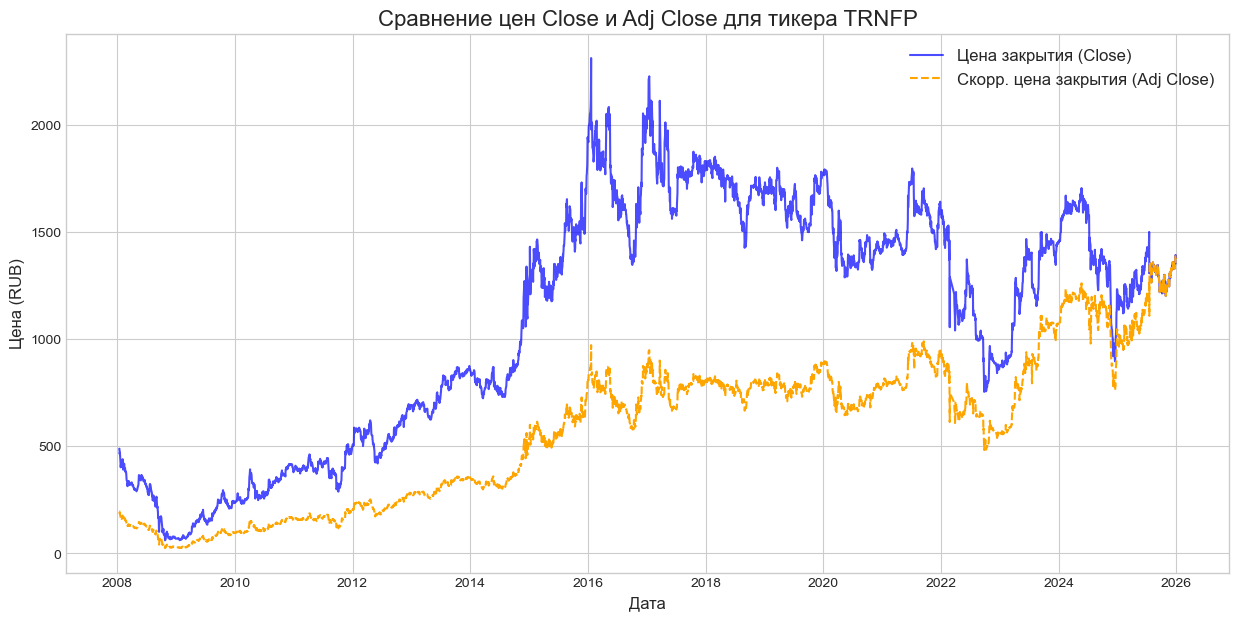

In [21]:
plt.style.use('seaborn-v0_8-whitegrid') #  приятный стиль для графика
plt.figure(figsize=(15, 7)) # Задаем размер графика

plt.plot(df.index, df['close'], label='Цена закрытия (Close)', color='blue', alpha=0.7)

# Проверяем наличие adj_close перед использованием
if 'adj_close' in df.columns:
    plt.plot(df.index, df['adj_close'], label='Скорр. цена закрытия (Adj Close)', color='orange', linestyle='--')
else:
    print("Warning: adj_close не найден. Используйте moex.calculate_adj_close() для расчета.")

# Добавляем название и подписи осей
ticker_name = df['ticker'].iloc[0] if 'ticker' in df.columns and len(df) > 0 else 'Unknown'
plt.title(f"Сравнение цен Close и Adj Close для тикера {ticker_name}", fontsize=16)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Цена (RUB)', fontsize=12)

# Включаем легенду, чтобы было понятно, какая линия что означает
plt.legend(fontsize=12)

# Показываем график
plt.show()


## Собрать все данные в один датасет 

In [20]:
# Combine all stock data
combined_stocks = moex.combine_moex_stocks()

# Basic statistics
print("\nBasic statistics:")
print(combined_stocks.describe())

Loaded data for AFKS
Loaded data for AFLT
Loaded data for AGRO
Loaded data for AKRN
Loaded data for ALRS
Loaded data for ASTR
Loaded data for BANE
Loaded data for BANEP
Loaded data for BSPB
Loaded data for CBOM
Loaded data for CHMF
Loaded data for DIXY
Loaded data for DSKY
Loaded data for ENPG
Loaded data for EONR
Loaded data for EPLN
Loaded data for FEES
Loaded data for FIVE
Loaded data for FIXP
Loaded data for FLOT
Loaded data for GAZP
Loaded data for GCHE
Loaded data for GLTR
Loaded data for GMKN
Loaded data for HEAD
Loaded data for HHRU
Loaded data for HYDR
Loaded data for IRAO
Loaded data for KMAZ
Loaded data for LEAS
Loaded data for LKOH
Loaded data for LNTA
Loaded data for LSRG
Loaded data for MAGN
Loaded data for MAIL
Loaded data for MDMG
Loaded data for MFON
Loaded data for MGNT
Loaded data for MOEX
Loaded data for MRKH
Loaded data for MSNG
Loaded data for MSRS
Loaded data for MSTT
Loaded data for MTLR
Loaded data for MTLRP
Loaded data for MTSS
Loaded data for MVID
Loaded data

In [21]:
#exclude = ["TRNFP", "SBERP"]  # список ненужных тикеров
#combined_stocks = combined_stocks[~combined_stocks["ticker"].isin(exclude)]
#combined_stocks

In [ ]:
def plot_stocks_performance(months = 1):
    """
    Calculates last month's performance for each stock and creates a horizontal bar chart.
    Performance is calculated as percentage change between the last prices of the first and last days.
    """
    import matplotlib.pyplot as plt
    
    # Get combined dataset
    combined_df = moex.combine_moex_stocks()
    
    # Проверка наличия необходимых колонок
    if 'ticker' not in combined_df.columns or 'close' not in combined_df.columns:
        raise ValueError("DataFrame должен содержать колонки 'ticker' и 'close'")
    
    # Get current date and date 1 month ago
    end_date = pd.Timestamp.now()
    start_date = end_date - pd.DateOffset(months = months)
    
    # Calculate performance for each stock
    performances = []
    
    for ticker in combined_df['ticker'].unique():
        # Get data for specific ticker
        stock_data = combined_df[combined_df['ticker'] == ticker]
        
        # Filter for last month and sort by date
        mask = (stock_data.index >= start_date) & (stock_data.index <= end_date)
        monthly_data = stock_data[mask].sort_index()
        
        if len(monthly_data) >= 2:  # Check if we have at least 2 data points
            # Get first and last day prices
            first_day = monthly_data.index.min()
            last_day = monthly_data.index.max()
            
            try:
                first_price = monthly_data.loc[first_day, 'close']
                last_price = monthly_data.loc[last_day, 'close']
                
                # Проверка на валидность цен
                if pd.isna(first_price) or pd.isna(last_price) or first_price <= 0:
                    continue
                
                # Calculate performance
                performance = ((last_price - first_price) / first_price) * 100
                performances.append({
                    'ticker': ticker,
                    'performance': performance,
                    'first_price': first_price,
                    'last_price': last_price,
                    'start_date': first_day,
                    'end_date': last_day
                })
            except (KeyError, IndexError) as e:
                print(f"Warning: Пропущен {ticker} из-за ошибки доступа к данным: {e}")
                continue
    
    if not performances:
        print("Нет данных для построения графика")
        return pd.DataFrame()
    
    # Create DataFrame with performances and sort
    perf_df = pd.DataFrame(performances)
    perf_df = perf_df.sort_values('performance', ascending=True)
    
    # Create horizontal bar chart
    plt.figure(figsize=(12, max(8, len(perf_df) * 0.3)))  # Adjust height based on number of stocks
    
    # Create horizontal bars
    bars = plt.barh(perf_df['ticker'], perf_df['performance'])
    
    # Customize the chart
    plt.title(f'Stock Performance за последние {months} месяц(ев) (%)', pad=20)
    plt.xlabel('Performance (%)')
    plt.ylabel('Ticker')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    
    # Add value labels on the bars
    for bar in bars:
        width = bar.get_width()
        x_pos = width if width >= 0 else width
        plt.text(x_pos, bar.get_y() + bar.get_height()/2,
                f'{width:.1f}%',
                ha='left' if width >= 0 else 'right', 
                va='center',
                fontweight='bold')
    
    # Color bars based on performance
    for bar in bars:
        if bar.get_width() >= 0:
            bar.set_color('green')
        else:
            bar.set_color('red')
    
    # Add zero line
    plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    
    # Adjust layout
    plt.tight_layout()
    
    # Show the plot
    plt.show()
    
    # Print detailed performance data
    print("\nPerformance Summary:")
    summary_df = perf_df[['ticker', 'performance', 'first_price', 'last_price', 'start_date', 'end_date']]
    print(summary_df.sort_values('performance', ascending=False).to_string())
    
    return perf_df


Loaded data for AFKS
Loaded data for AFLT
Loaded data for AGRO
Loaded data for AKRN
Loaded data for ALRS
Loaded data for ASTR
Loaded data for BANE
Loaded data for BANEP
Loaded data for BSPB
Loaded data for CBOM
Loaded data for CHMF
Loaded data for DIXY
Loaded data for DSKY
Loaded data for ENPG
Loaded data for EONR
Loaded data for EPLN
Loaded data for FEES
Loaded data for FIVE
Loaded data for FIXP
Loaded data for FLOT
Loaded data for GAZP
Loaded data for GCHE
Loaded data for GLTR
Loaded data for GMKN
Loaded data for HEAD
Loaded data for HHRU
Loaded data for HYDR
Loaded data for IRAO
Loaded data for KMAZ
Loaded data for LEAS
Loaded data for LKOH
Loaded data for LNTA
Loaded data for LSRG
Loaded data for MAGN
Loaded data for MAIL
Loaded data for MDMG
Loaded data for MFON
Loaded data for MGNT
Loaded data for MOEX
Loaded data for MRKH
Loaded data for MSNG
Loaded data for MSRS
Loaded data for MSTT
Loaded data for MTLR
Loaded data for MTLRP
Loaded data for MTSS
Loaded data for MVID
Loaded data

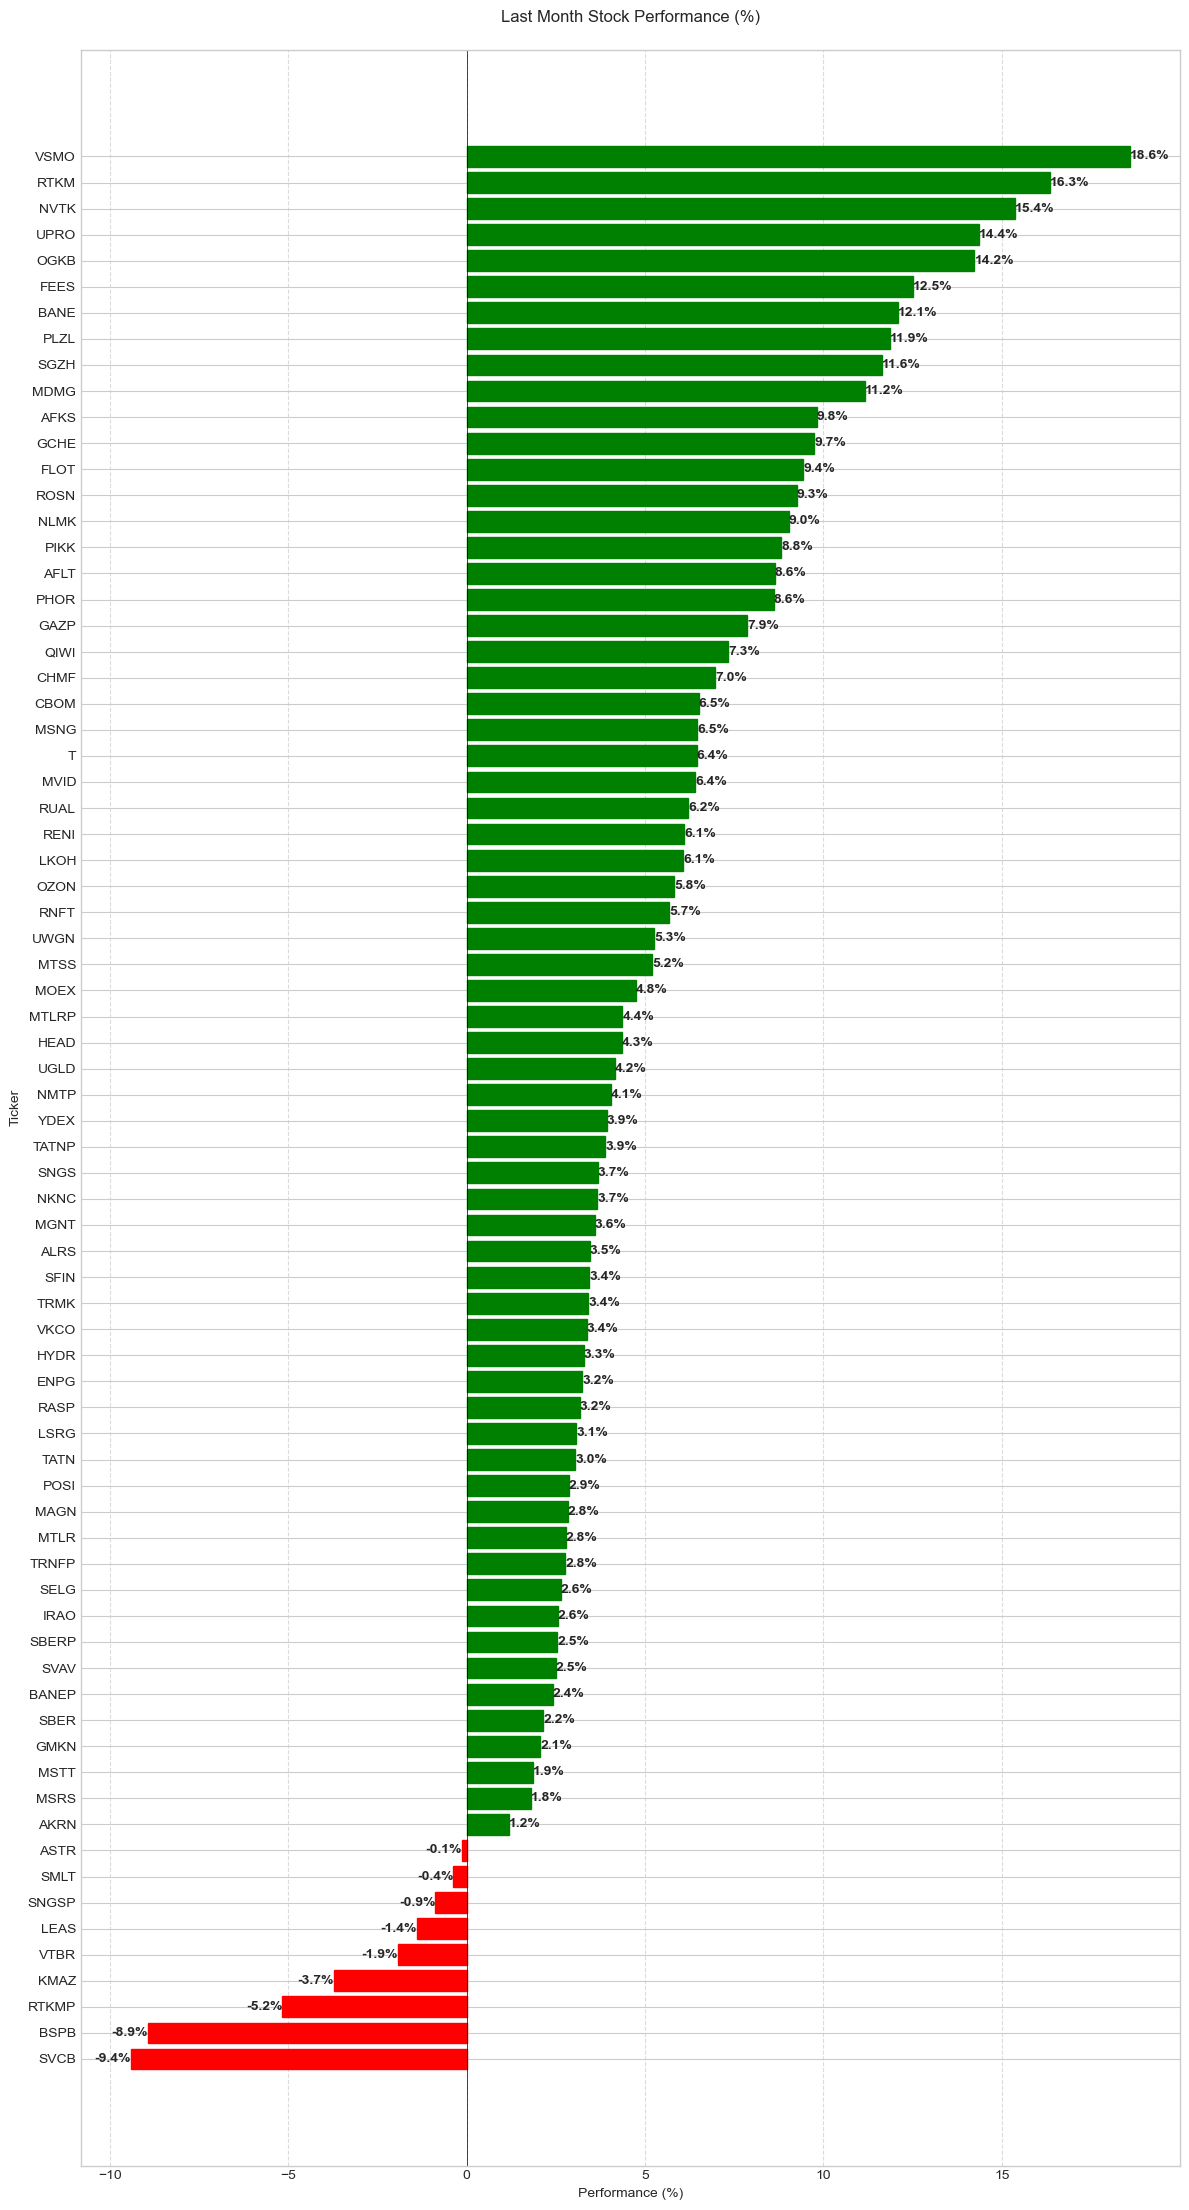


Performance Summary:
   ticker  performance  first_price  last_price start_date   end_date
71   VSMO     1859.44%  2732000.00% 3240000.00% 2025-07-31 2025-08-25
49   RTKM     1634.07%     6187.00%    7198.00% 2025-07-31 2025-08-25
37   NVTK     1536.19%   101420.00%  117000.00% 2025-07-31 2025-08-25
68   UPRO     1437.25%      148.20%     169.50% 2025-07-31 2025-08-25
38   OGKB     1423.46%       33.51%      38.28% 2025-07-31 2025-08-25
11   FEES     1250.38%        6.59%       7.41% 2025-07-31 2025-08-25
5    BANE     1209.98%   162400.00%  182050.00% 2025-07-31 2025-08-25
42   PLZL     1186.46%   196720.00%  220060.00% 2025-07-31 2025-08-25
56   SGZH     1163.27%      147.00%     164.10% 2025-07-31 2025-08-25
24   MDMG     1115.54%   112950.00%  125550.00% 2025-07-31 2025-08-25
0    AFKS      981.16%     1539.00%    1690.00% 2025-07-31 2025-08-25
14   GCHE      974.59%   334500.00%  367100.00% 2025-07-31 2025-08-25
12   FLOT      943.49%     8087.00%    8850.00% 2025-07-31 2025-08-2

,ticker,performance,first_price,last_price,start_date,end_date
61,SVCB,-940.52%,1706.50%,1546.00%,2025-07-31,2025-08-25
7,BSPB,-893.13%,39815.00%,36259.00%,2025-07-31,2025-08-25
50,RTKMP,-516.63%,7065.00%,6700.00%,2025-07-31,2025-08-25
19,KMAZ,-371.52%,9690.00%,9330.00%,2025-07-31,2025-08-25
72,VTBR,-192.88%,7777.00%,7627.00%,2025-07-31,2025-08-25
...,...,...,...,...,...,...
38,OGKB,1423.46%,33.51%,38.28%,2025-07-31,2025-08-25
68,UPRO,1437.25%,148.20%,169.50%,2025-07-31,2025-08-25
37,NVTK,1536.19%,101420.00%,117000.00%,2025-07-31,2025-08-25
49,RTKM,1634.07%,6187.00%,7198.00%,2025-07-31,2025-08-25


In [28]:
# Usage
plot_stocks_performance(1)

## Доходность за последние 10 лет 


In [ ]:
years = 12
latest_date = combined_stocks.index.max()
ten_years_ago = latest_date - pd.DateOffset(years=years)
df_filtered = combined_stocks[combined_stocks.index >= ten_years_ago].copy()
# Сортируем данные по тикеру и дате (индексу), чтобы убедиться, что они в правильном порядке
df_filtered = df_filtered.sort_values(by='ticker').sort_index()
ten_years_ago

Timestamp('2013-08-25 00:00:00')

In [25]:
# --- Функция для расчета CAGR ---
def calculate_cagr(prices_series):
    """Рассчитывает CAGR для временного ряда цен."""
    if prices_series.empty or len(prices_series) < 2:
        return None
    
    start_value = prices_series.iloc[0]
    end_value = prices_series.iloc[-1]
    
    start_date = prices_series.index.min()
    end_date = prices_series.index.max()
    
    time_delta_years = (end_date - start_date).days / 365.25
    
    if time_delta_years > 0 and start_value > 0:
        cagr = ((end_value / start_value)**(1/time_delta_years)) - 1
        return cagr
    else:
        return None

In [ ]:
results_list = []

for ticker, group in df_filtered.groupby('ticker'):
    
    # 1. Проверка на полноту истории
    min_date = group.index.min()
    max_date = group.index.max()
    # Считаем историю полной, если первая дата - не позже 30 дней от начала периода,
    # а последняя - не раньше 30 дней до конца периода.
    is_history_full = (min_date - ten_years_ago).days < 30 and (latest_date - max_date).days < 30
    
    # 2. Расчет CAGR для adj_close и close
    # Проверяем наличие колонок перед использованием
    if 'adj_close' not in group.columns:
        print(f"Warning: {ticker} не имеет adj_close. Используется close для расчета.")
        cagr_adj_close = calculate_cagr(group['close'])
    else:
        cagr_adj_close = calculate_cagr(group['adj_close'])
    
    cagr_close = calculate_cagr(group['close'])
    
    # 3. Расчет дивидендной доходности
    avg_div_yield = None
    if cagr_adj_close is not None and cagr_close is not None:
        avg_div_yield = cagr_adj_close - cagr_close
        
    results_list.append({
        'ticker': ticker,
        'cagr_total': cagr_adj_close,
        'cagr_price': cagr_close,
        'avg_div_yield': avg_div_yield,
        'has_full_history': is_history_full
    })


In [ ]:
# --- Создание и форматирование итоговой таблицы ---
results_df = pd.DataFrame(results_list).set_index('ticker')

# Сортировка по общей доходности (adj_close)
results_df.sort_values(by='cagr_total', ascending=False, inplace=True)

# Устанавливаем формат вывода в процентах (сохраняем старое значение для восстановления)
old_format = pd.options.display.float_format
pd.options.display.float_format = '{:.2%}'.format
print("Анализ доходности акций за последние 10 лет:")
print(results_df)
# Восстанавливаем формат (опционально, можно закомментировать если нужен процентный формат везде)
# pd.options.display.float_format = old_format


Анализ доходности акций за последние 10 лет:
        cagr_total  cagr_price  avg_div_yield  has_full_history
ticker                                                         
TNBPP      693.44%     693.44%          0.00%             False
PLZL       116.51%      30.42%         86.08%              True
IRAO        66.30%      58.77%          7.53%              True
RUALR       41.05%      41.05%          0.00%             False
AKRN        34.42%      25.94%          8.48%              True
...            ...         ...            ...               ...
FIXP       -32.03%     -32.03%          0.00%             False
MAIL       -34.34%     -34.34%          0.00%             False
MRKH       -66.32%     -66.32%          0.00%             False
POGR       -81.84%     -81.84%          0.00%             False
GMKN           NaN       8.95%            NaN              True

[97 rows x 4 columns]


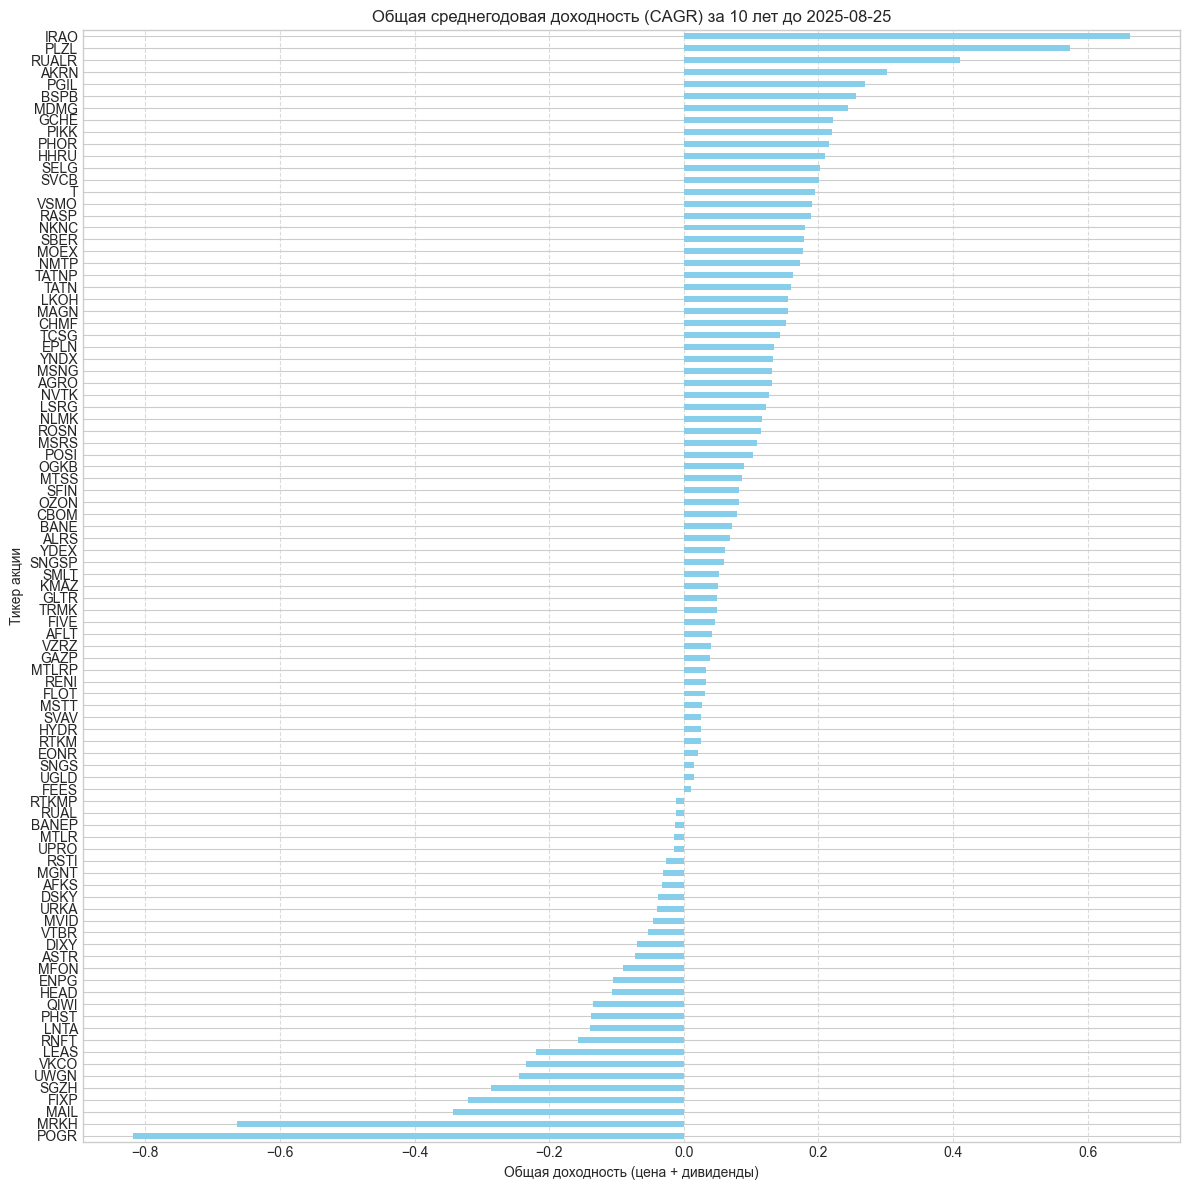

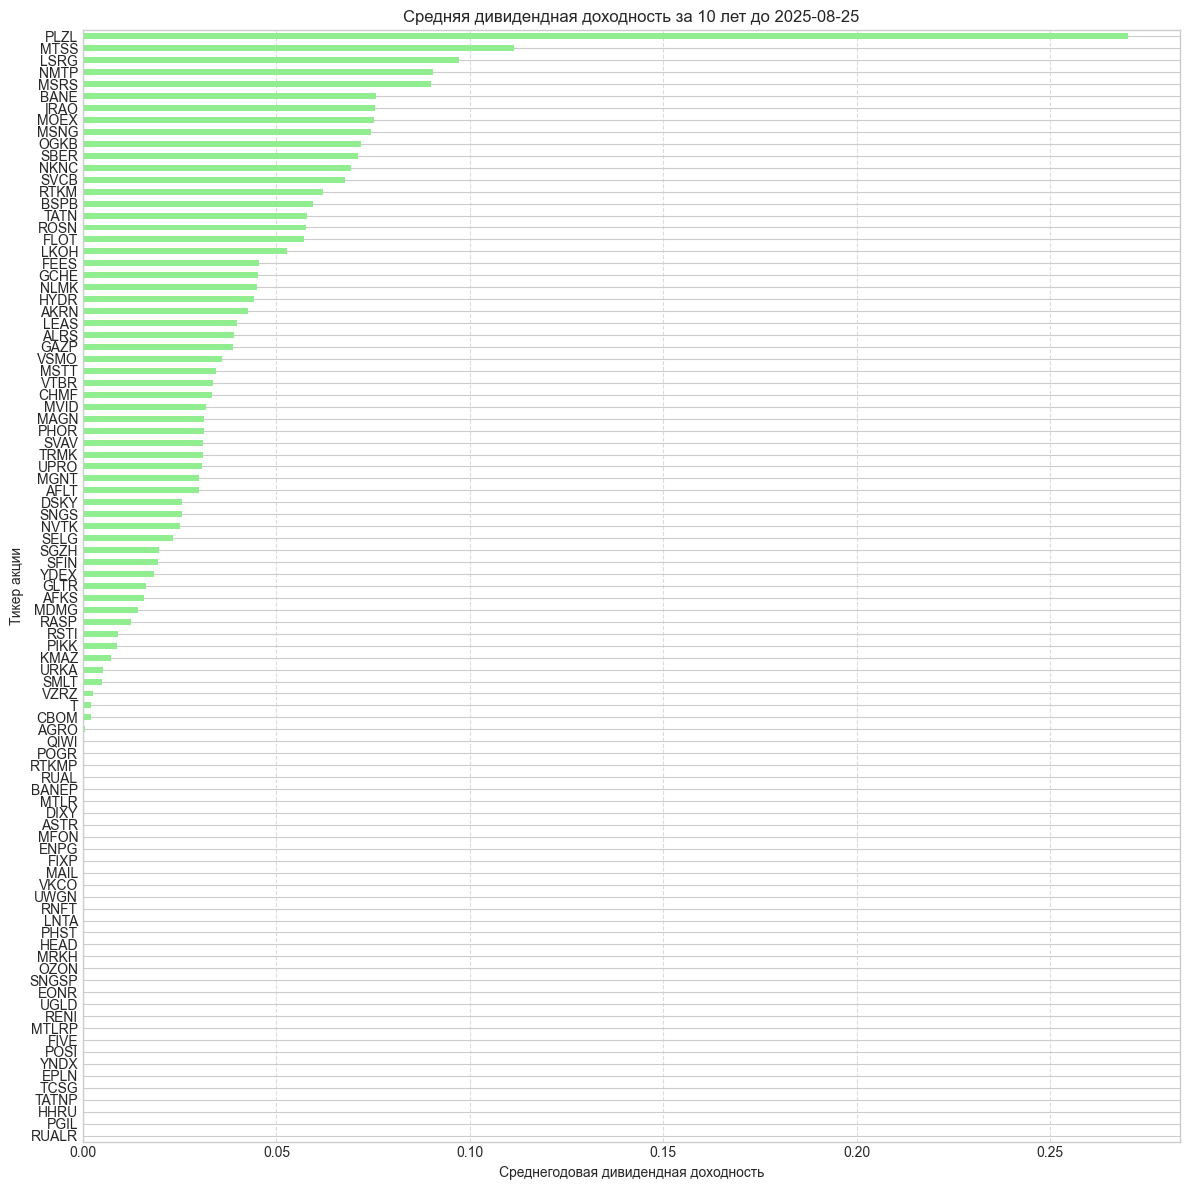

In [66]:
# График 1: Общая среднегодовая доходность (CAGR по adj_close)
results_df_sorted_total = results_df.dropna(subset=['cagr_total']).sort_values('cagr_total', ascending=True)
plt.figure(figsize=(12, 12))
results_df_sorted_total['cagr_total'].plot(kind='barh', color='skyblue')

plt.title(f'Общая среднегодовая доходность (CAGR) за 10 лет до {latest_date.strftime("%Y-%m-%d")}')
plt.xlabel('Общая доходность (цена + дивиденды)')
plt.ylabel('Тикер акции')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# График 2: Среднегодовая дивидендная доходность
results_df_sorted_div = results_df.dropna(subset=['avg_div_yield']).sort_values('avg_div_yield', ascending=True)
plt.figure(figsize=(12, 12))
results_df_sorted_div['avg_div_yield'].plot(kind='barh', color='lightgreen')

plt.title(f'Средняя дивидендная доходность за 10 лет до {latest_date.strftime("%Y-%m-%d")}')
plt.xlabel('Среднегодовая дивидендная доходность')
plt.ylabel('Тикер акции')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()